In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from ptlpinns.models import train_PDE, model, transfer_wave
from ptlpinns.odes import numerical
from ptlpinns.perturbation import LKV
import torch
from scipy.integrate import solve_ivp
import numpy as np

/home/jovyan/PTL-PINNs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Transfer parameters

In [2]:
L, T = 2, 5
x_span, t_span = (0, L), (0, T) 

Nx, Nt = 50, 50
x, t, grid = train_PDE.generate_interior_tensor(IG=(Nx, Nt), x_span=(0, L), t_span=(0, T), require_grad=False)

X_grid = np.linspace(0, L, Nx)
t_eval = np.linspace(0, T, Nt)
mesh_x, mesh_t = np.meshgrid(X_grid, t_eval)

In [3]:
c, D = 1, 1
epsilon = 0.5
epsilons = [epsilon]
p = 5

def ic_sin(input):
    x = input[:, 0].unsqueeze(1)
    return (torch.sin(torch.pi * x / L))

def constant_function(constant):
    '''return a function input  ((x,t)in torch) -> constant, can be given as function.

    for example constant_function(0) will return a function that returns 0 for any input.
    '''
    def forcing_function_constant(input):
        return constant*torch.ones_like(input[:, 0].unsqueeze(1))
    return forcing_function_constant

icD = ic_sin
icN = constant_function(0)
bcs = [constant_function(0), constant_function(0)] 
Polynomial = [[1,3]]
forcing=constant_function(0)

In [4]:
def solution_wave(epsilons, c, polynomial, x_span, t_span, Nx, Nt, u0, v0, forcing, bcs, method="RK45", atol=1e-10, rtol=1e-10):
 
    Numerical_solutions = np.zeros((len(epsilons), Nx, Nt))
    
    for i in range(len(epsilons)):
        x = np.linspace(x_span[0], x_span[1], Nx)
        dx = x[1] - x[0]
        t = np.linspace(t_span[0], t_span[1], Nt)
        
        # Convert second-order PDE to system of first-order ODEs
        def rhs(t, y):
            """
            y = [u, v] where v = u_t
            y[:Nx] = u (displacement)
            y[Nx:] = v (velocity)
            """
            u = y[:Nx]
            v = y[Nx:]
            
            # Initialize second derivative
            u_xx = np.zeros_like(u)
            
            # Apply boundary conditions to u
            u[0] = bcs[i][0](t) if callable(bcs[i][0]) else bcs[i][0]
            u[-1] = bcs[i][1](t) if callable(bcs[i][1]) else bcs[i][1]
            
            # Compute second spatial derivative (central difference)
            u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / (dx**2)
            
            # Apply boundary conditions to second derivative if needed
            # For Dirichlet BCs, u_xx at boundaries can be computed from neighbors
            if callable(bcs[i][0]):
                # Left boundary: use one-sided difference
                u_xx[0] = (u[2] - 2*u[1] + u[0]) / (dx**2)
            else:
                u_xx[0] = 0
                
            if callable(bcs[i][1]):
                # Right boundary: use one-sided difference  
                u_xx[-1] = (u[-1] - 2*u[-2] + u[-3]) / (dx**2)
            else:
                u_xx[-1] = 0
            
            # System of equations:
            du_dt = v  # u_t = v
            dv_dt = c**2 * u_xx - epsilons[i] * polynomial[i](u) + forcing[i](x, t)  # v_t = c^2 u_xx - ε N(u) + f
            
            return np.concatenate([du_dt, dv_dt])
        
        # Initial conditions
        u_initial = u0[i](x)
        v_initial = v0[i](x)
        y0 = np.concatenate([u_initial, v_initial])
        
        # Solve the system
        sol = solve_ivp(rhs, t_span=t_span, y0=y0, t_eval=t, method=method, rtol=rtol, atol=atol)
        
        # Extract displacement solution (first Nx components)
        Numerical_solutions[i, :, :] = sol.y[:Nx, :]
    
    return Numerical_solutions

def polynomial_nonlinearity(u):
    return u**3

polynomial = [polynomial_nonlinearity]

def initial_displacement(x):
    return (np.sin(np.pi * x / 2))

def initial_velocity(x):
    return np.zeros_like(x)

def forcing_func(x, t):
    return np.zeros_like(x) 

def left_bc(t):
    return 0.0

def right_bc(t):
    return 0.0

u0 = [initial_displacement]
v0 = [initial_velocity]  

# Solve
numerical_solution = solution_wave(epsilons, c, polynomial, x_span, t_span, Nx, Nt, 
                        u0, v0, [lambda x, t: np.zeros_like(x)], [(left_bc, right_bc)])[0]

### Load the model

In [5]:
name = "model_Wave_linear.pth"
path = "/home/jovyan/PTL-PINNs/ptlpinns/models/train/Wave_linear"
pinn = model.Multihead_model_PDE(k=9, bias=True)
pinn.load_state_dict(torch.load(f'{path}/{name}'))

bias = True
w_pde, w_bc, w_ic = 1, 10, 10

training_log = {
    'name': name,
    'bias': bias,
    'k' : 9,
    'domain_info':{
        'L': L,
        'T': T,},
    'Nx' : Nx,
    'Nt' : Nt,
    'w_pde': w_pde,
    'w_bc': w_bc,
    'w_ic': w_ic,}

### Validate Multi-head

In [6]:
H_dict = transfer_wave.compute_H_dict(model = pinn,IG = (Nx,Nt),Nic = Nx,Nbc = Nt, bias = False,x_span= x_span,t_span= t_span,log = training_log)

Differentiating H w.r.t. x now...
Finished computing H2x.
Differentiating H w.r.t. t now...
Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc


In [7]:
_, _, _ = transfer_wave.compute_M(H_dict= H_dict,w_pde=1,w_ic=10,w_bc=10)
_, H_dict = transfer_wave.compute_R_ic(H_dict,ic_functionD=icD, ic_functionN=icN, w_ic=10,log=training_log)
_,_,_,H_dict = transfer_wave.compute_R_bcs(H_dict,boundary_functions=bcs ,w_bc=10, log=training_log)

In [8]:
input = torch.cat((x.unsqueeze(1), t.unsqueeze(1)), dim=1) 
NN_TL_pertubation_solution, _ = transfer_wave.compute_perturbation_solution_polynomial_complete(p, epsilon,H_dict=H_dict, input=input,training_log=training_log, forcing=forcing,Polynomial=Polynomial,boundary_functions=bcs,ic_functionD=icD,ic_functionN=icN)
NN_TL_pertubation_solution = NN_TL_pertubation_solution.reshape(Nx, Nt)

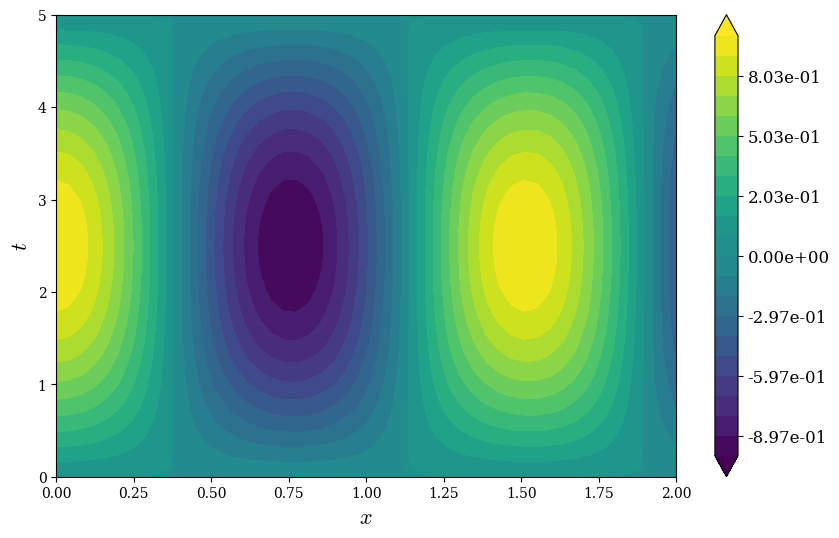

In [9]:
numerical.plot_solution_PDE(numerical_solution, mesh_x, mesh_t, surface=False)

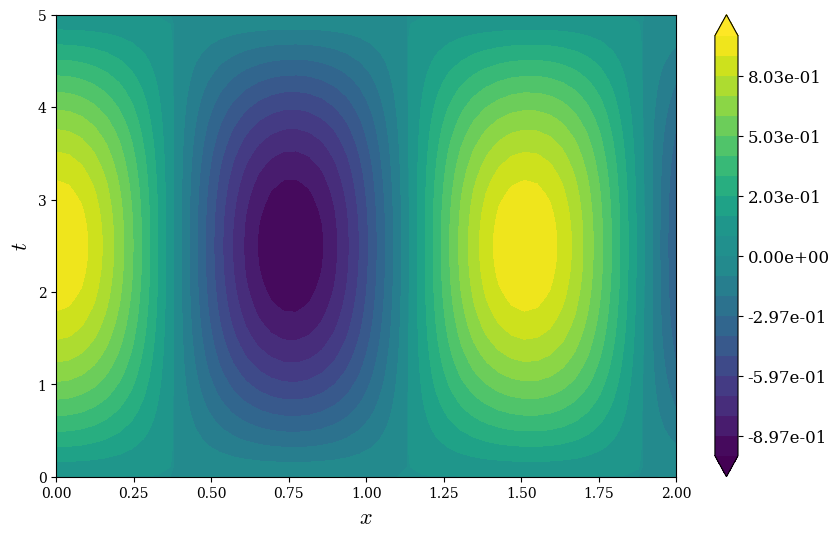

In [10]:
numerical.plot_solution_PDE(NN_TL_pertubation_solution, mesh_x, mesh_t, surface=False)

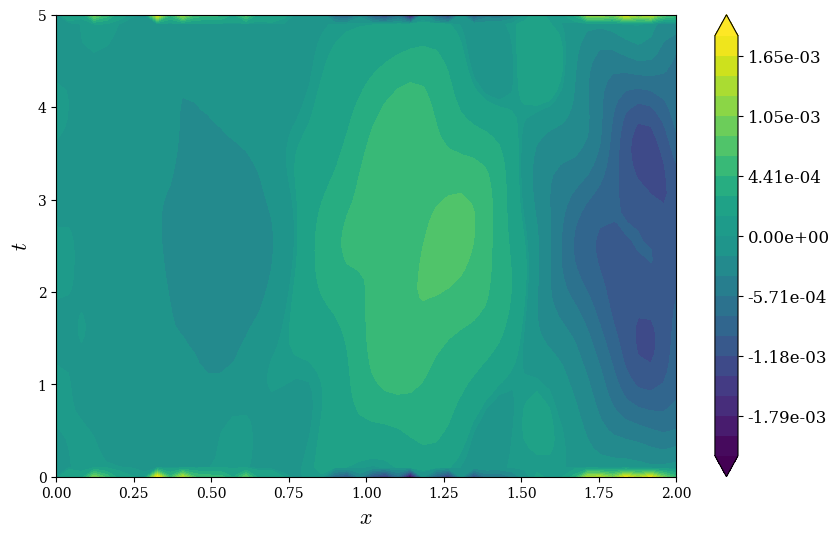

In [11]:
numerical.plot_solution_PDE(NN_TL_pertubation_solution - numerical_solution, mesh_x, mesh_t, surface=False)

In [12]:
np.mean(np.abs(NN_TL_pertubation_solution - numerical_solution))

np.float64(0.0002935579676488528)

In [13]:
numerical_solution_low_acc_RK45 = solution_wave(epsilons, c, polynomial, x_span, t_span, Nx, Nt, 
                        u0, v0, [lambda x, t: np.zeros_like(x)], [(left_bc, right_bc)], atol=1e-3, rtol=1e-3)[0]

numerical_solution_low_acc_Radau = solution_wave(epsilons, c, polynomial, x_span, t_span, Nx, Nt, 
                        u0, v0, [lambda x, t: np.zeros_like(x)], [(left_bc, right_bc)], atol=1e-3, rtol=1e-3, method="Radau")[0]

In [14]:
np.mean(np.abs(numerical_solution_low_acc_RK45 - numerical_solution))

np.float64(0.0010634634549259332)

In [15]:
np.mean(np.abs(numerical_solution_low_acc_Radau - numerical_solution))

np.float64(0.0005631544364756105)

### MAE vs perturbation order — pretrained PTL-PINN

Differentiating H w.r.t. x now...
Finished computing H2x.
Differentiating H w.r.t. t now...
Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc


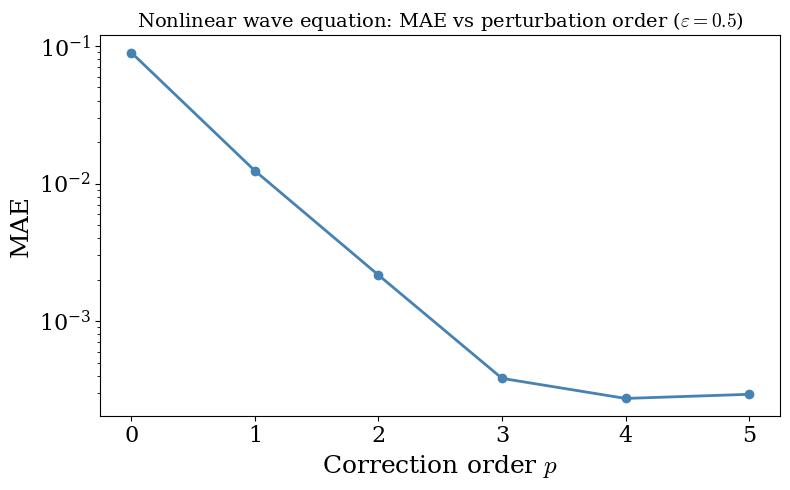

In [16]:
input_plot    = torch.cat((x.unsqueeze(1), t.unsqueeze(1)), dim=1)
forcing_plot  = constant_function(0)
bcs_plot      = [constant_function(0), constant_function(0)]

errors_pretrained, _ = transfer_wave.compute_error_per_order_wave(
    model=pinn,
    IG=(Nx, Nt), Nic=Nx, Nbc=Nt, bias=False,
    x_span=x_span, t_span=t_span,
    training_log=training_log, c=c,
    p_max=p,
    epsilon=epsilon,
    forcing=forcing_plot,
    Polynomial=Polynomial,
    ic_functionD=icD,
    ic_functionN=icN,
    boundary_functions=bcs_plot,
    input_interior=input_plot,
    reference_solution=numerical_solution,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    np.arange(len(errors_pretrained)),
    errors_pretrained,
    marker="o",
    linewidth=2.0,
    color="steelblue",
)
ax.set_yscale("log")
ax.set_xlabel("Correction order $p$", fontsize=18)
ax.set_ylabel("MAE", fontsize=18)
ax.tick_params(labelsize=16)
ax.set_title(
    rf"Nonlinear wave equation: MAE vs perturbation order ($\varepsilon={epsilon}$)",
    fontsize=14,
)
plt.tight_layout()
plt.show()

## Random-basis benchmark — MAE vs perturbation order

The nonlinear wave equation
\[
  u_{tt} \;=\; c^{2}\,u_{xx} \;-\; \varepsilon\,u^{3},
  \qquad u(x,0) = \sin(\pi x / L),\quad u_t(x,0)=0,\quad u(0,t)=u(L,t)=0
\]
is solved with the polynomial perturbation series on top of **untrained
(random) `Multihead_model_PDE` feature banks** `H`, sweeping over two grids:

1. **Activation × size grid (9 benchmarks).** All combinations of
   - activation $\in$ {`relu`, `sin`, `tanh`}, and
   - hidden layout $\in$ {`[64, 64, 128]`, `[128, 128, 256]`, `[256, 256, 512]`}.

2. **Random-weight magnitude grid (5 benchmarks).** For the best
   (activation, size) combination found in grid 1, every backbone weight is
   re-scaled by a factor `weight_scale` $\in$
   {`1e-2`, `1e-1`, `1`, `10`, `100`} after the default initialisation,
   controlling the magnitude of the random weights that define `H`.

The **pretrained PINN** (`model_Wave_linear.pth`, `[100, 100, 350]`) is shown
on both plots **in red** as the trained baseline.

For each configuration we record the MAE of the cumulative PTL-PINN solution
$\sum_{k=0}^{p} \varepsilon^k u_k(x,t)$ against the high-resolution Radau
reference `numerical_solution`, for every perturbation order
$p = 0,\dots,p_{\max}$.  (`relu` has a vanishing second derivative, so for a
second-order-in-time equation its operator can be singular — such configs are
caught and reported rather than crashing the sweep.)

In [17]:
import torch.nn as nn

# --- Benchmark grids --------------------------------------------------------
# Grid 1: 3 activations x 3 hidden-layer sizes  ->  9 random feature banks.
ACTIVATIONS = {
    "relu": nn.ReLU(),
    "sin":  torch.sin,
    "tanh": nn.Tanh(),
}
SIZES = [[64, 64, 128], [128, 128, 256], [256, 256, 512]]

# Grid 2: random-weight magnitudes applied to the best combo from grid 1.
WEIGHT_SCALES = [1e-2, 1e-1, 1.0, 10.0, 100.0]

# Colour reserved for the pretrained baseline curve in every plot.
BASELINE_COLOR = "red"


def _make_pretrained_pinn_wave():
    """Load the actual (pretrained) model used in the rest of the notebook."""
    m = model.Multihead_model_PDE(k=9, bias=True)
    m.load_state_dict(torch.load(f'{path}/{name}'))
    return m


def _make_random_pinn_wave(hidden_layers, act=nn.Tanh(), weight_scale=1.0, seed=0):
    """Untrained `Multihead_model_PDE` with a chosen activation, hidden-layer
    sizes and random-weight magnitude.  `weight_scale` multiplies every
    backbone weight/bias after the default initialisation, so it sets the
    magnitude of the random weights that define the feature bank H (the head
    layers do not enter H and are left untouched)."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    m = model.Multihead_model_PDE(
        k=training_log['k'], bias=training_log['bias'],
        hidden_layers=hidden_layers, act=act,
    )
    if weight_scale != 1.0:
        with torch.no_grad():
            for pname, param in m.named_parameters():
                if not pname.startswith("final_layers"):
                    param.mul_(weight_scale)
    return m


p_max = p   # use the same perturbation order as the main experiment (5)

# Re-build the problem data for the sweep helpers (matches the
# perturbation cell above).
ic_sweepD     = icD                          # Dirichlet IC (displacement)
ic_sweepN     = icN                          # Neumann IC   (velocity)
bcs_sweep     = [constant_function(0), constant_function(0)]
forcing_sweep = constant_function(0)
Polynomial_sweep = Polynomial                # [[1, 3]]  (i.e. +u^3)
input_interior   = torch.cat((x.unsqueeze(1), t.unsqueeze(1)), dim=1)


def _run_wave_config(pinn_cfg):
    """Run one feature bank through the PTL-PINN solve and return
    (errors_per_order, H_dict)."""
    return transfer_wave.compute_error_per_order_wave(
        model=pinn_cfg,
        IG=(Nx, Nt), Nic=Nx, Nbc=Nt, bias=False,
        x_span=x_span, t_span=t_span,
        training_log=training_log, c=c,
        p_max=p_max, epsilon=epsilon,
        forcing=forcing_sweep,
        Polynomial=Polynomial_sweep,
        ic_functionD=ic_sweepD,
        ic_functionN=ic_sweepN,
        boundary_functions=bcs_sweep,
        input_interior=input_interior,
        reference_solution=numerical_solution,
    )

In [18]:
# --- Grid 1: 3 activations x 3 sizes = 9 random-basis benchmarks ------------
errors_by_label = {}
H_dict_by_label = {}
grid1_results   = []   # (act_name, size, err, cond_H)

for act_name, act_fn in ACTIVATIONS.items():
    for size in SIZES:
        label = f"{act_name} ({size})"
        try:
            pinn_cfg = _make_random_pinn_wave(size, act=act_fn)
            err, H_cfg = _run_wave_config(pinn_cfg)
        except Exception as exc:
            print(f"{label:<24s}  FAILED: {type(exc).__name__}: {exc}")
            continue

        cond_H = np.linalg.cond(H_cfg['H'])
        legend_label = (
            f"{label}  [$\\kappa(H)$={cond_H:.1e}, "
            f"MAE@$p$={len(err) - 1}: {err[-1]:.2e}]"
        )
        errors_by_label[legend_label] = err
        H_dict_by_label[label] = H_cfg
        grid1_results.append((act_name, size, err, cond_H))
        print(f"{label:<24s}  MAE @ p={len(err) - 1}: {err[-1]:.3e}  |  cond(H)={cond_H:.2e}")

# Pretrained baseline — drawn in red on every plot.
err_base, H_base = _run_wave_config(_make_pretrained_pinn_wave())
cond_base = np.linalg.cond(H_base['H'])

Differentiating H w.r.t. x now...
Finished computing H2x.
Differentiating H w.r.t. t now...
Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc
relu ([64, 64, 128])      MAE @ p=5: 4.186e-01  |  cond(H)=2.40e+37
Differentiating H w.r.t. x now...
Finished computing H2x.
Differentiating H w.r.t. t now...
Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc
relu ([128, 128, 256])    MAE @ p=5: 6.344e-01  |  cond(H)=2.36e+52
Differentiating H w.r.t. x now...
Finished computing H2x.
Differentiating H w.r.t. t now...
Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc
relu ([256, 256, 512])    MAE @ p=5: 4.021e-01  |  cond(H)=9.46e+52
Differentiating H w.r.t. x now...
Finished computing H2x.
Differentiating H w.r.t. t now...
Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc
sin ([64, 64, 128])       MAE @ p=5: 3.363e-03  |  cond(H)=1.89e+11
Differentiating H w.

Pretrained ([100,100,350])  MAE @ p=5: 2.936e-04  |  cond(H)=3.02e+09


/home/jovyan/PTL-PINNs/ptlpinns/perturbation/LKV.py:360: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, which="both", alpha=0.3)


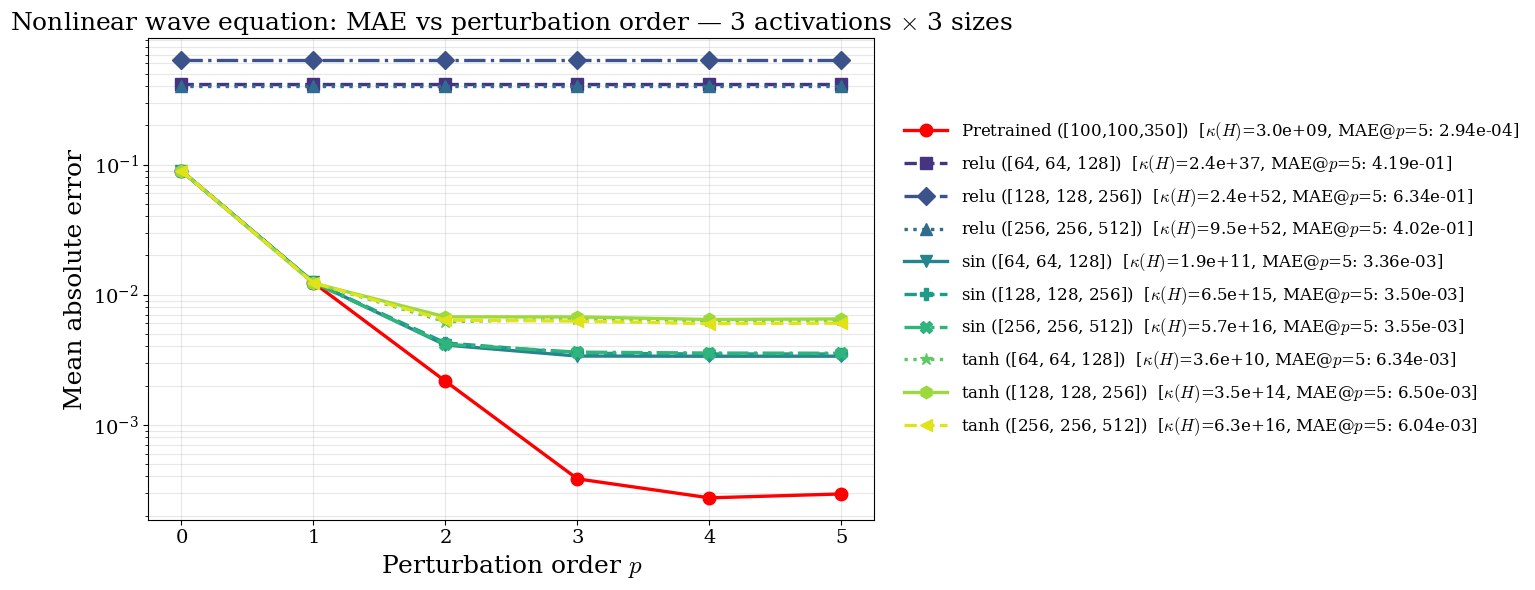

(<Figure size 1500x600 with 1 Axes>,
 <Axes: title={'center': 'Nonlinear wave equation: MAE vs perturbation order — 3 activations $\\times$ 3 sizes'}, xlabel='Perturbation order $p$', ylabel='Mean absolute error'>)

In [ ]:
baseline_label = (
    f"Pretrained ([100,100,350])  [$\\kappa(H)$={cond_base:.1e}, "
    f"MAE@$p$={len(err_base) - 1}: {err_base[-1]:.2e}]"
)
H_dict_by_label["Pretrained ([100,100,350])"] = H_base
print(f"{'Pretrained ([100,100,350])':<24s}  MAE @ p={len(err_base) - 1}: {err_base[-1]:.3e}  |  cond(H)={cond_base:.2e}")

LKV.plot_mae_vs_order(
    {baseline_label: err_base, **errors_by_label},
    title="Nonlinear wave equation: MAE vs perturbation order — 3 activations $\\times$ 3 sizes",
    color_overrides={baseline_label: BASELINE_COLOR},
    grid=False, figsize=(15, 6)
)

Best combo from grid 1: activation=sin, size=[64, 64, 128]

Differentiating H w.r.t. x now...
Finished computing H2x.
Differentiating H w.r.t. t now...
Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc
sin [64, 64, 128]  |w|x0.01     MAE @ p=5: 4.263e-01  |  cond(H)=4.50e+17
Differentiating H w.r.t. x now...
Finished computing H2x.
Differentiating H w.r.t. t now...
Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc
sin [64, 64, 128]  |w|x0.1      MAE @ p=5: 4.737e-01  |  cond(H)=1.65e+17
Differentiating H w.r.t. x now...
Finished computing H2x.
Differentiating H w.r.t. t now...
Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc
sin [64, 64, 128]  |w|x1        MAE @ p=5: 3.363e-03  |  cond(H)=1.89e+11
Differentiating H w.r.t. x now...
Finished computing H2x.
Differentiating H w.r.t. t now...
Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc
sin [64, 6

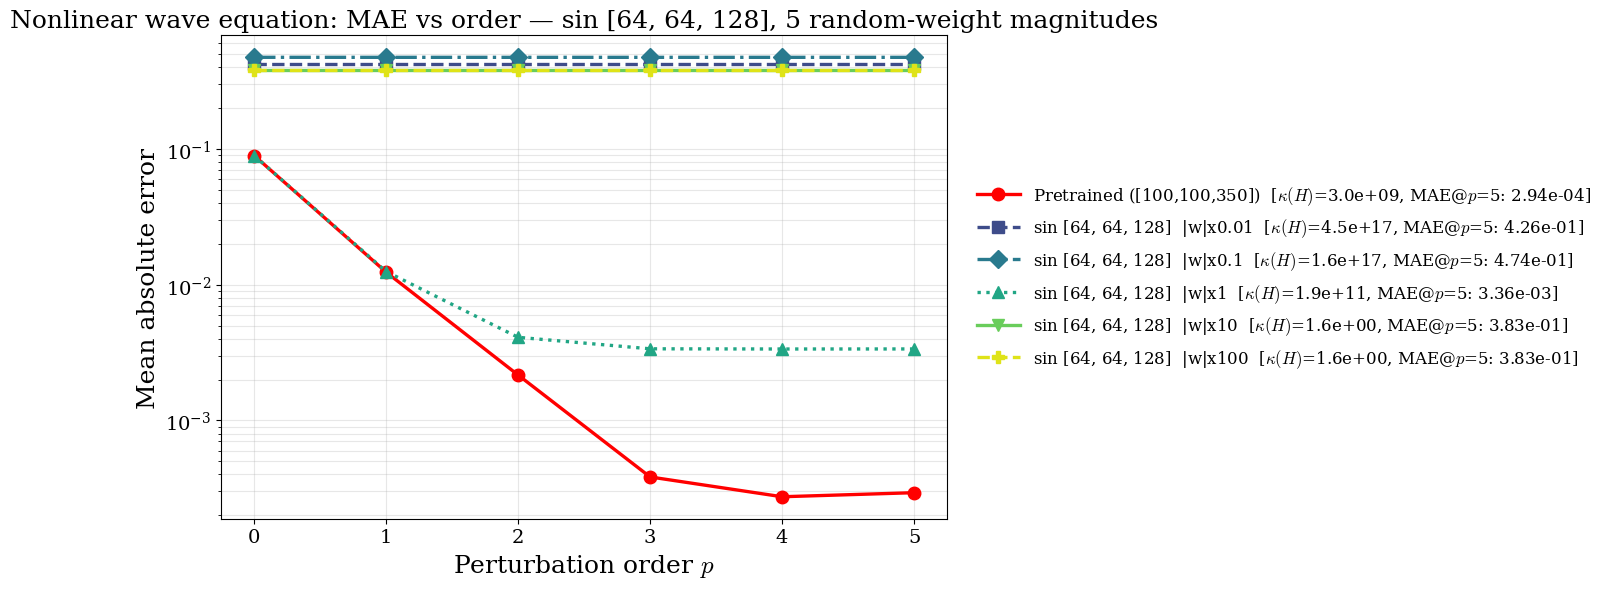

(<Figure size 1500x600 with 1 Axes>,
 <Axes: title={'center': 'Nonlinear wave equation: MAE vs order — sin [64, 64, 128], 5 random-weight magnitudes'}, xlabel='Perturbation order $p$', ylabel='Mean absolute error'>)

In [20]:
# --- Grid 2: best (activation, size) combo over 6 random-weight magnitudes --
best_act, best_size, _, _ = min(grid1_results, key=lambda r: r[2][-1])
print(f"Best combo from grid 1: activation={best_act}, size={best_size}\n")

errors_by_scale = {}
for scale in WEIGHT_SCALES:
    label = f"{best_act} {best_size}  |w|x{scale:g}"
    try:
        pinn_cfg = _make_random_pinn_wave(
            best_size, act=ACTIVATIONS[best_act], weight_scale=scale,
        )
        err, H_cfg = _run_wave_config(pinn_cfg)
    except Exception as exc:
        print(f"{label:<30s}  FAILED: {type(exc).__name__}: {exc}")
        continue

    cond_H = np.linalg.cond(H_cfg['H'])
    legend_label = (
        f"{label}  [$\\kappa(H)$={cond_H:.1e}, "
        f"MAE@$p$={len(err) - 1}: {err[-1]:.2e}]"
    )
    errors_by_scale[legend_label] = err
    print(f"{label:<30s}  MAE @ p={len(err) - 1}: {err[-1]:.3e}  |  cond(H)={cond_H:.2e}")

LKV.plot_mae_vs_order(
    {baseline_label: err_base, **errors_by_scale},
    title=f"Nonlinear wave equation: MAE vs order — {best_act} {best_size}, {len(WEIGHT_SCALES)} random-weight magnitudes",
    color_overrides={baseline_label: BASELINE_COLOR},
    grid=False, figsize=(15, 6)
)